In [1]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from scipy.signal import periodogram

simplefilter("ignore")

In [4]:
# Set Matplotlib defaults
sns.set_style('whitegrid')
plt.rc("figure", autolayout=True, figsize=(16, 6))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'


def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    # from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax


data_dir = Path("../../Time Series/store-sales-time-series-forecasting")
oil = pd.read_csv(data_dir / "oil.csv", parse_dates=["date"])
oil = oil.set_index("date").to_period("D")

oil['dcoilwtico'].fillna(oil["dcoilwtico"].mean(), inplace=True)

<Axes: title={'center': 'Seasonal Plot (year/dayofyear)'}, xlabel='dayofyear', ylabel='dcoilwtico'>

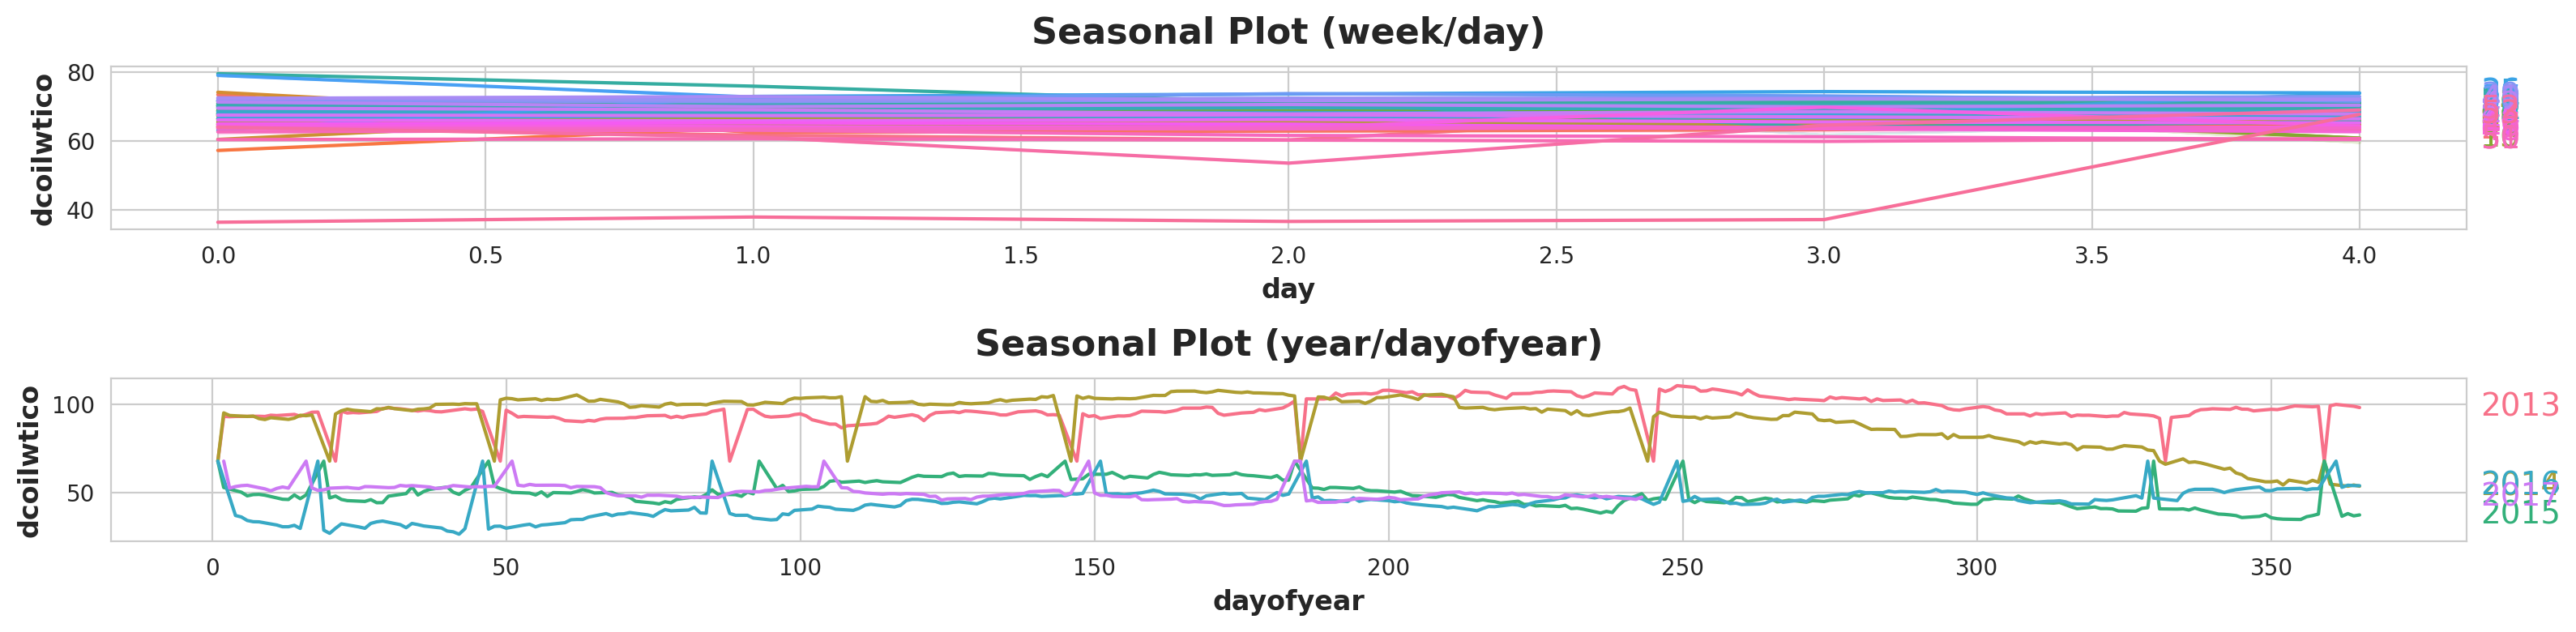

In [5]:
oil_copy = oil.copy()
X = oil.copy()

X["day"] = X.index.dayofweek
X['week'] = X.index.week

X['dayofyear'] = X.index.dayofyear
X['year'] = X.index.year

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(16, 4))
seasonal_plot(X, y='dcoilwtico', period='week', freq='day', ax=ax0)
seasonal_plot(X, y='dcoilwtico', period='year', freq='dayofyear', ax=ax1)

<Axes: title={'center': 'Periodogram'}, ylabel='Variance'>

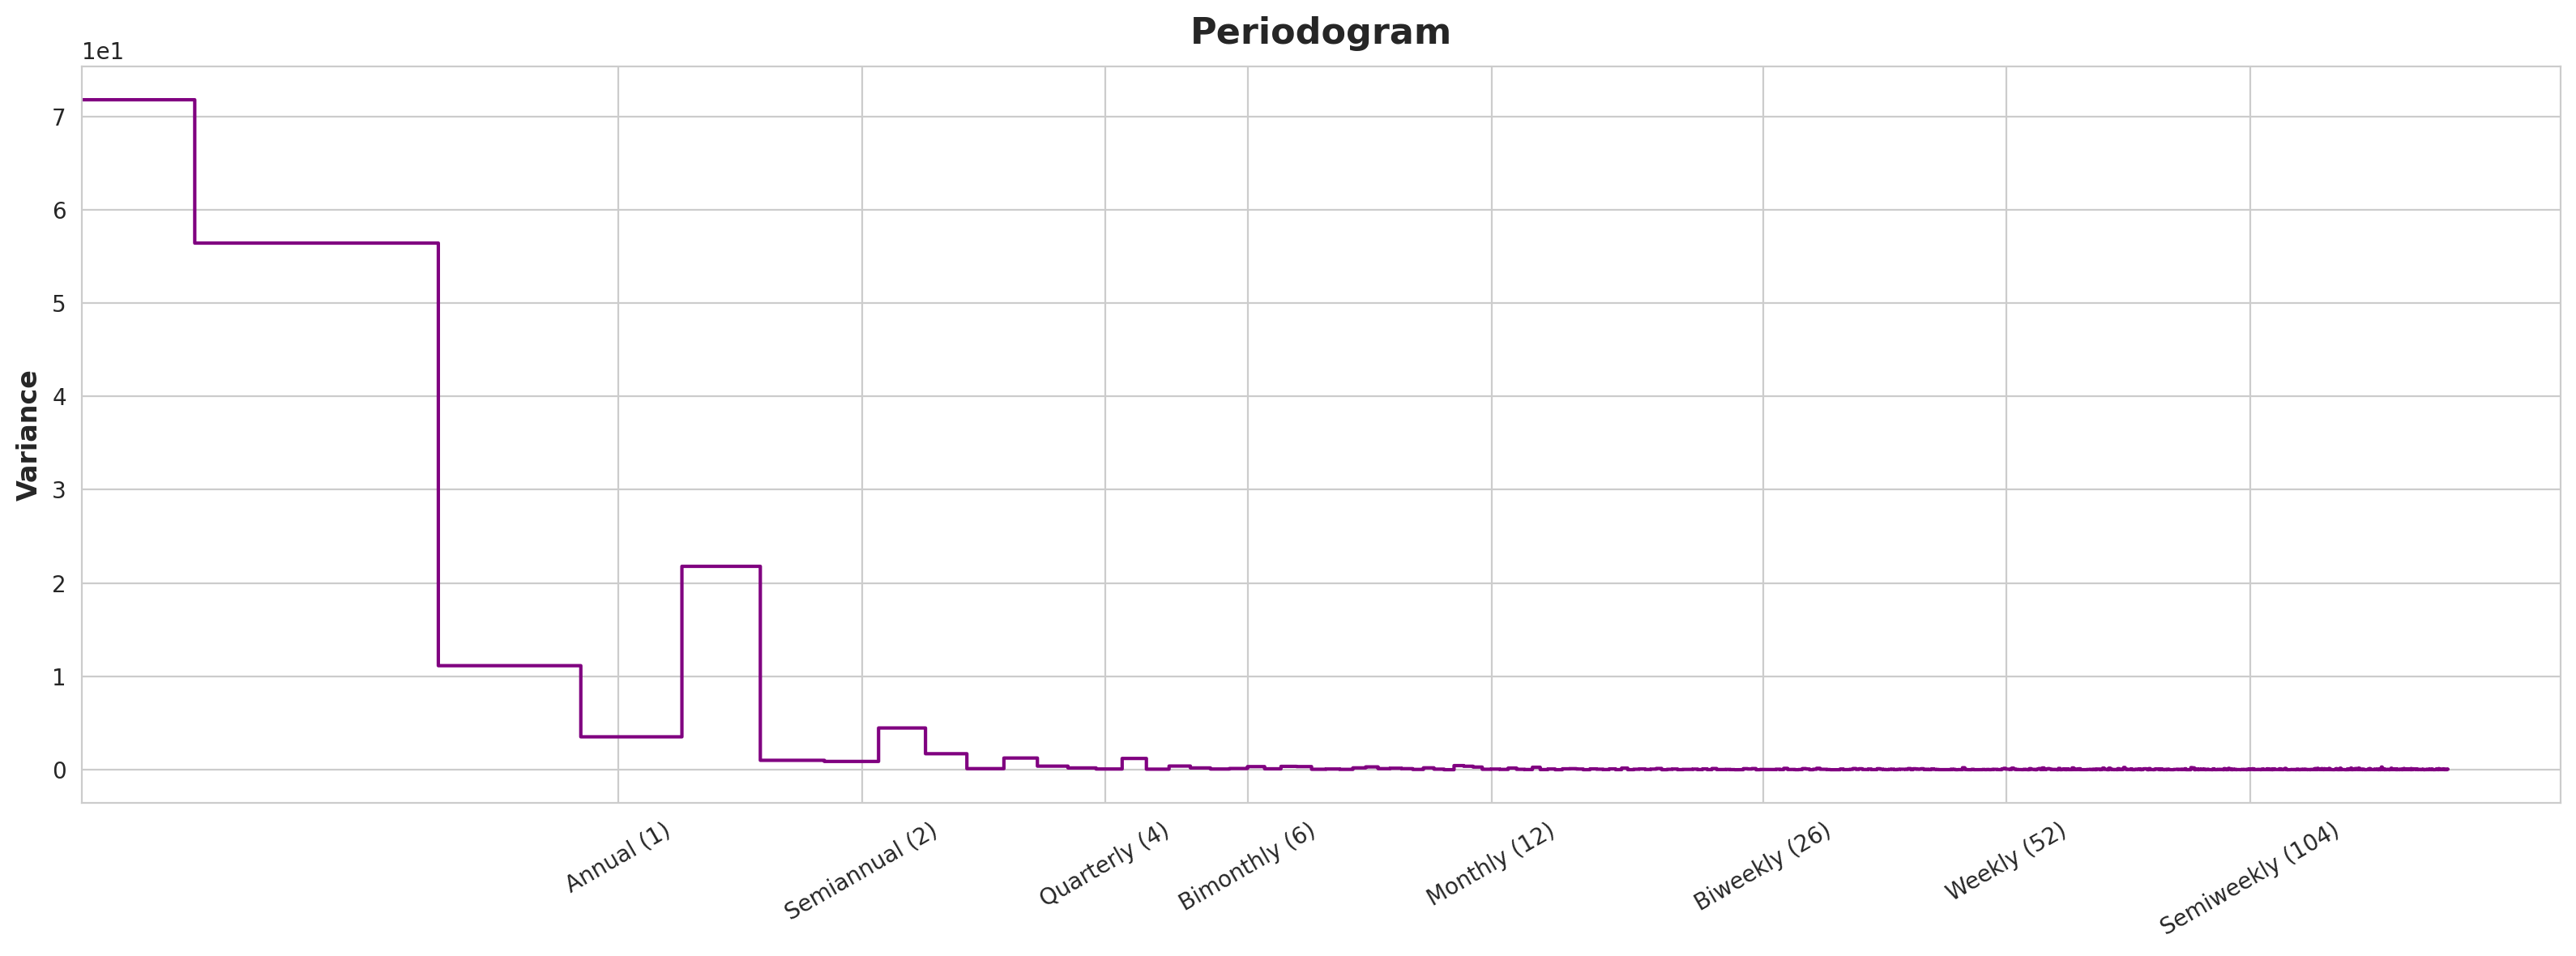

In [6]:
plot_periodogram(oil_copy.dcoilwtico)

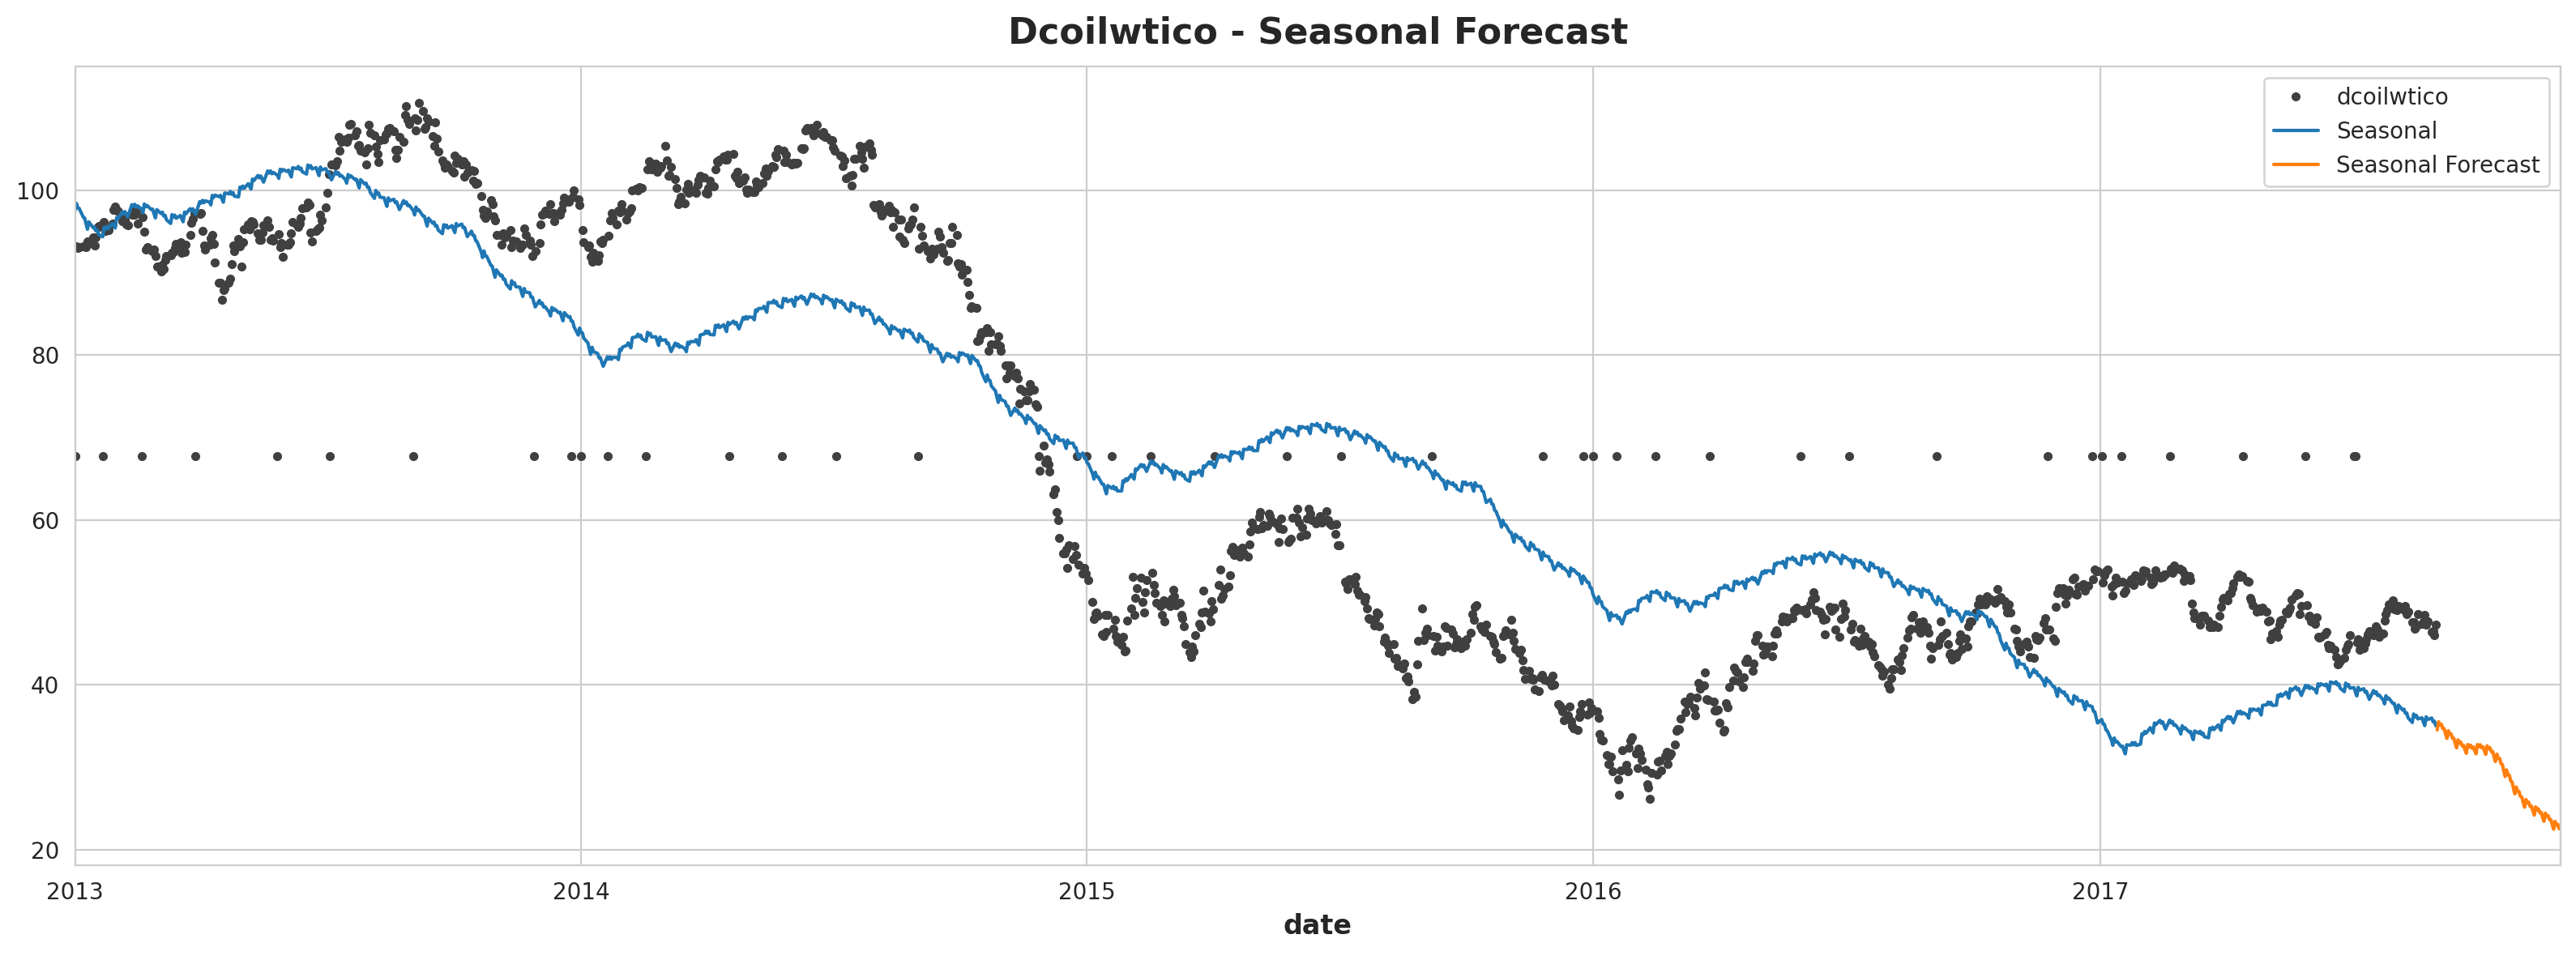

In [9]:
fourier = CalendarFourier(freq="A", order=10)

dp = DeterministicProcess(
    index=oil_copy.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True
)

X = dp.in_sample()
y = oil_copy['dcoilwtico']

lm_model = LinearRegression(fit_intercept=False)
_ = lm_model.fit(X, y)

y_pred = pd.Series(lm_model.predict(X), index=y.index)
X_fore = dp.out_of_sample(steps=90)
y_fore = pd.Series(lm_model.predict(X_fore), index=X_fore.index)

ax = y.plot(color='0.25', style='.', title='Dcoilwtico - Seasonal Forecast')
ax = y_pred.plot(ax=ax, label="Seasonal")
ax = y_fore.plot(ax=ax, label="Seasonal Forecast")
_ = ax.legend()